### Introdução à Análise de Texto com Processamento de Linguagem Natural (NLP)

In [1]:
try:
    import pandas as pd
except ImportError as e:
    %pip install pandas
    import pandas as pd

In [2]:
try:
    import os
except ImportError as e:
    %pip install os
    import os

In [3]:
try:
    import sklearn
except ImportError as e:
    %pip install scikit-learn
    import sklearn

In [4]:
from sklearn.model_selection import train_test_split


In [5]:
from sklearn.linear_model import LogisticRegression

In [6]:
curr_dir = os.getcwd()
path = os.path.join(curr_dir, 'data', 'imdb-reviews-pt-br.csv')
resenhas = pd.read_csv(path)

In [7]:
resenhas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49459 entries, 0 to 49458
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         49459 non-null  int64 
 1   text_en    49459 non-null  object
 2   text_pt    49459 non-null  object
 3   sentiment  49459 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.5+ MB


In [8]:
resenhas.head()

,id,text_en,text_pt,sentiment
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg


In [9]:
resenhas

,id,text_en,text_pt,sentiment
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg
...,...,...,...,...
49454,49456,"Seeing as the vote average was pretty low, and...","Como a média de votos era muito baixa, e o fat...",pos
49455,49457,"The plot had some wretched, unbelievable twist...",O enredo teve algumas reviravoltas infelizes e...,pos
49456,49458,I am amazed at how this movieand most others h...,Estou espantado com a forma como este filme e ...,pos
49457,49459,A Christmas Together actually came before my t...,A Christmas Together realmente veio antes do m...,pos


In [10]:
treino, teste, label_treino, label_teste = train_test_split(resenhas.text_pt,
                                                              resenhas.sentiment,
                                                              random_state= 42)

In [11]:
regressao_logistica = LogisticRegression()
#regressao_logistica.fit(treino, label_treino)
#acuracia = regressao_logistica.score(teste, label_teste)
#print(acuracia)

# o comando acima dá erro, pois os dados são strings e o modelo de regressão logística só aceita números. 
# para resolver isso, precisamos transformar os textos em números, utilizando uma técnica chamada "bag of words".

> Regressão logística/logistic regression: técnica de classificação binária, será utilizada aqui para mapear as previsões em 0 e 1 (análise negativa e positiva)

#### Explorando o dataset

In [12]:
resenhas.shape

(49459, 4)

In [13]:
# exemplo de mensagem negativa de treino
print("Negativa: \n")
print(resenhas.text_pt[220])

Negativa: 

Um dos piores filmes que eu já vi! Depois de assistir eu saio como, o que aconteceu? Estou confuso até hoje, alguém pode me explicar esse filme, por favor? tanto a qualidade de atuação quanto a de imagem são tão ruins que você pensa que está assistindo a um projeto escolar de alguém feito com uma câmera de vídeo caseira. Primeiro, eu não posso acreditar que como algumas pessoas poderiam dar 10 estrelas para este filme. Porque, seu filme incrivelmente ruim! Este filme não é assustador em tudo! Também não há clichês de terror típicos. O enredo e atuação deste filme foi terrível. Não é fantástico, surrealista ou de terror, é apenas um filme cinematográfico turco horrivelmente ruim. E, finalmente, houve muitas cenas desnecessárias e personagens desnecessários. Quando eu assisto Gomeda eu caí em tão desesperado, tão triste para o jovem cineasta turco.Por favor, por favor, não faça cinema assim!


In [14]:
# exemplo de mensagem positiva de treino
print("Positiva: \n")
print(resenhas.text_pt[42500])

Positiva: 

Comecei a assistir a um replay desse filme de TV em uma tarde de domingo, pensando que era apenas mais um filme de desastre de avião idiota. Eu estava errado. "Pandora Clock" é um thriller político inteligente que está muito além da qualidade da maioria dos filmes de TV. Poderia facilmente ter feito sua estréia na telona. O elenco é excelente, incluindo os veteranos Richard Dean Anderson, Edward Herrmann, Robert Guillaume e Robert Loggia. Daphne Zuniga faz um de seus melhores desempenhos como especialista médica trabalhando para a CIA, e Frasiers Jane Leeves também é muito boa. O diálogo é bem escrito e a história é convincente por toda parte. Na verdade, a hora final é tão cheia de reviravoltas e suspense que você não pode deixar seu lugar por um segundo. Se você tiver a chance de ver esse filme, invista o tempo - quase quatro horas. Você será ricamente recompensado!


In [15]:
print(resenhas.sentiment.value_counts()) # ignorando a divisão teste e treino, pois estou olhando se o dataset completo está balanceado ou não

sentiment
neg    24765
pos    24694
Name: count, dtype: int64


In [16]:
# como é mais comum utilizar 0 e 1 para a classificação binária/regressão logística, adiciono essa coluna no dataframe
classificacao = resenhas['sentiment'].replace(['neg', 'pos'], [0, 1])
classificacao

C:\Users\noteb\AppData\Local\Temp\ipykernel_10856\3977780138.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  classificacao = resenhas['sentiment'].replace(['neg', 'pos'], [0, 1])


0        0
1        0
2        0
3        0
4        0
        ..
49454    1
49455    1
49456    1
49457    1
49458    1
Name: sentiment, Length: 49459, dtype: int64

In [17]:
resenhas['classificacao'] = classificacao
resenhas.head()

,id,text_en,text_pt,sentiment,classificacao
0,1,Once again Mr. Costner has dragged out a movie...,"Mais uma vez, o Sr. Costner arrumou um filme p...",neg,0
1,2,This is an example of why the majority of acti...,Este é um exemplo do motivo pelo qual a maiori...,neg,0
2,3,"First of all I hate those moronic rappers, who...","Primeiro de tudo eu odeio esses raps imbecis, ...",neg,0
3,4,Not even the Beatles could write songs everyon...,Nem mesmo os Beatles puderam escrever músicas ...,neg,0
4,5,Brass pictures movies is not a fitting word fo...,Filmes de fotos de latão não é uma palavra apr...,neg,0


In [18]:
resenhas.tail()

,id,text_en,text_pt,sentiment,classificacao
49454,49456,"Seeing as the vote average was pretty low, and...","Como a média de votos era muito baixa, e o fat...",pos,1
49455,49457,"The plot had some wretched, unbelievable twist...",O enredo teve algumas reviravoltas infelizes e...,pos,1
49456,49458,I am amazed at how this movieand most others h...,Estou espantado com a forma como este filme e ...,pos,1
49457,49459,A Christmas Together actually came before my t...,A Christmas Together realmente veio antes do m...,pos,1
49458,49460,Working-class romantic drama from director Mar...,O drama romântico da classe trabalhadora do di...,pos,1


Neste primeiro momento, iremos utilizar a representação bag of words para representar as palavras em um vetor 

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

texto = ["Assisti um filme ótimo", "Assisti um filme ruim"]

vetorizar = CountVectorizer(lowercase=False)
bag_of_words = vetorizar.fit_transform(texto) # fit transform é utilizado para "treinar" o count vectorizer
bag_of_words

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (2, 5)>

In [20]:
vocabulario = vetorizar.get_feature_names_out() # para ver todas as palavras salvas

In [21]:
matriz_esparsa = pd.DataFrame.sparse.from_spmatrix(bag_of_words, columns=vocabulario) # utilizo a estrutura de dados para matrizes esparsas para criar um dataframe eficiente no uso da memória

In [22]:
matriz_esparsa

,Assisti,filme,ruim,um,ótimo
0,1,1,0,1,1
1,1,1,1,1,0


Aplicando a representação bag of words nos dados reais do IMDb

In [23]:
vetorizar = CountVectorizer(lowercase=False, max_features=100) # iremos limitar o número de palavras/tokens únicos aos 50 mais comuns
bag_of_words = vetorizar.fit_transform(resenhas.text_pt) # iremos utilizar os dados em português
print(bag_of_words.shape) # resposta original: (49459, 156923)

(49459, 100)


Utilizo a representação bag of words dos dados para realizar a regressão logística (como agora os dados são numéricos, não dá erro) 

In [24]:
treino, teste, label_treino, label_teste = train_test_split(bag_of_words,
                                                            resenhas.classificacao,
                                                            random_state= 42)

regressao_logistica = LogisticRegression()
regressao_logistica.fit(treino, label_treino)
acuracia = regressao_logistica.score(teste, label_teste)
print(acuracia)

0.7014961585119288


In [25]:
def classificar_texto(texto, coluna_texto, coluna_classificacao):
    vetorizar = CountVectorizer(lowercase=False, max_features=50)
    bag_of_words = vetorizar.fit_transform(texto[coluna_texto])

    treino, teste, label_treino, label_teste = train_test_split(bag_of_words,
                                                            texto[coluna_classificacao],
                                                            random_state= 42)
    
    regressao_logistica = LogisticRegression()
    regressao_logistica.fit(treino, label_treino)
    acuracia = regressao_logistica.score(teste, label_teste)
    return acuracia

print(classificar_texto(resenhas, 'text_pt', 'classificacao'))

0.6583097452486858


In [26]:
try:
    import wordcloud
except ImportError as e:
    %pip install wordcloud
    import wordcloud


In [27]:
from wordcloud import WordCloud

todas_palavras = ' '.join([texto for texto in resenhas.text_pt]) # junto todas as palavras em uma única string para criar a wordcloud
print(f"Total de caracteres na string: {len(todas_palavras)}")

nuvem_palavras = WordCloud(width=800, height=500,max_font_size=110,
                           collocations=False).generate(todas_palavras) # collocations = False garante que apareca as palavras em si, não os bigramas (padrão de duas palavras seguidas)

Total de caracteres na string: 63448424


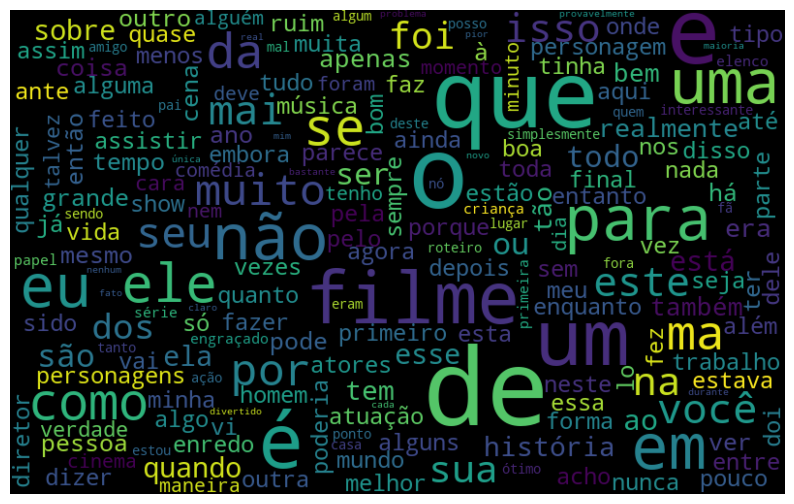

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.imshow(nuvem_palavras, interpolation='bilinear')
plt.axis("off")
plt.show()

Faço uma nova nuvem de palavras para identificar melhor quais são as que mais aparecem negativa e positivamente

In [29]:
def nuvem_palavras_neg(texto, coluna_texto):
    texto_negativo = texto.query("sentiment == 'neg'")

    todas_palavras = ' '.join([texto for texto in texto_negativo[coluna_texto]]) 
    nuvem_palavras = WordCloud(width=800, height=500,max_font_size=110,
                            collocations=False).generate(todas_palavras)
    
    plt.figure(figsize=(10, 7))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis("off")
    plt.show()


In [30]:
def nuvem_palavras_pos(texto, coluna_texto):
    texto_positivo = texto.query("sentiment == 'pos'")

    todas_palavras = ' '.join([texto for texto in texto_positivo[coluna_texto]]) 
    nuvem_palavras = WordCloud(width=800, height=500,max_font_size=110,
                            collocations=False).generate(todas_palavras)
    
    plt.figure(figsize=(10, 7))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis("off")
    plt.show()

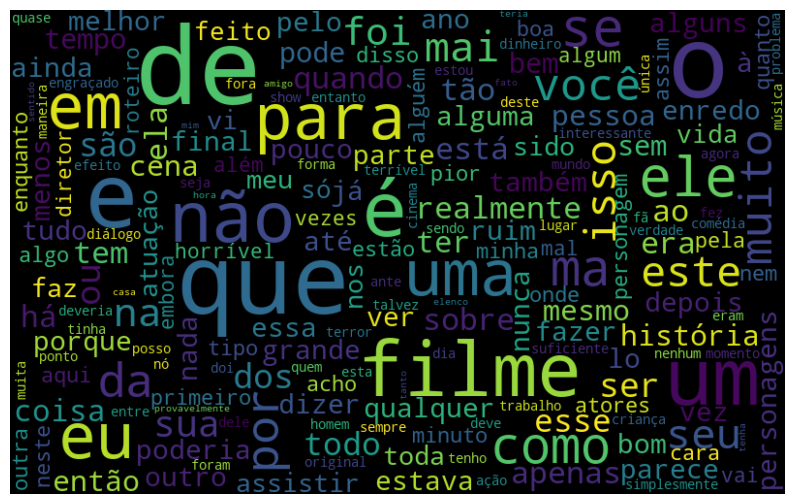

In [31]:
nuvem_palavras_neg(resenhas, "text_pt")

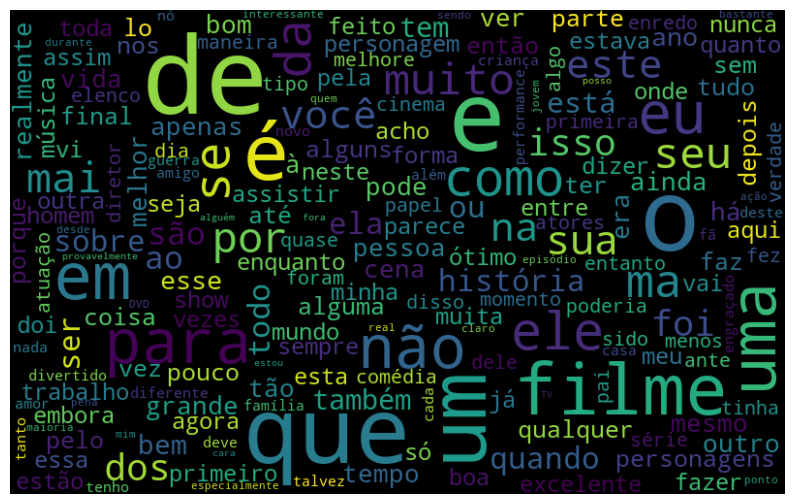

In [32]:
nuvem_palavras_pos(resenhas, "text_pt")

Utilizaremos a biblioteca nttk para separar as frases em tokens e conseguir um dicionário de frequência das palavras do dataset

In [33]:
try:
    import nltk
except ImportError as e:
    %pip install nltk
    import nltk

nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\noteb\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\noteb\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\noteb\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\noteb\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\noteb\AppData\Roaming\nltk_data...
[

True

In [36]:
import nltk
frase = ["um filme bom", "um filme ruim", "um filme ótimo", "um filme péssimo"]
frequencia = nltk.FreqDist(frase)
frequencia

FreqDist({'um filme bom': 1, 'um filme ruim': 1, 'um filme ótimo': 1, 'um filme péssimo': 1})

In [ ]:
from nltk import tokenize

frase = "Bem vindo ao mundo do PLN!"
token_espaco = tokenize.WhitespaceTokenizer()
token_frase = token_espaco.tokenize(frase)

['Bem', 'vindo', 'ao', 'mundo', 'do', 'PLN!']


In [38]:
print(token_frase)

['Bem', 'vindo', 'ao', 'mundo', 'do', 'PLN!']


In [ ]:
token_frase = token_espaco.tokenize(todas_palavras) # separando as frases do dataset por tokens
frequencia = nltk.FreqDist(token_frase)

In [40]:
frequencia

FreqDist({'de': 417651, 'que': 325070, 'e': 299743, 'o': 244881, 'um': 216410, 'a': 210179, 'é': 192381, 'em': 132778, 'uma': 130888, 'não': 127915, ...})